In [158]:

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [226]:
# filename = '/Users/rishi/Documents/Analysis/palmer/aerie-apps_bin4-9__allsky_1024_i2.5_r0.0_p1.0.fits.gz'
filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p5-index2p7-padding1p0-bins_8910_GP.fits'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p0-index2p7-padding1p0-bins_8910_GP.fits'
x = 5
y =  0
# x = 357.3
# y =  42.7
xlength = 10
ylength = 8
coord_sys = 'G' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)

ROI center in Galactic Coordintes = 5, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 5.0 0.0 
CRPIX : 1800.0 1440.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 3600  2880
Fits File loaded
Degrees per pixel: 0.005555555555555556 


# Use either the make plots command or plot directly

Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (1445, 379)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (12.89044859, 0.03331358)>
Peak intensity value: 43.93219798373834


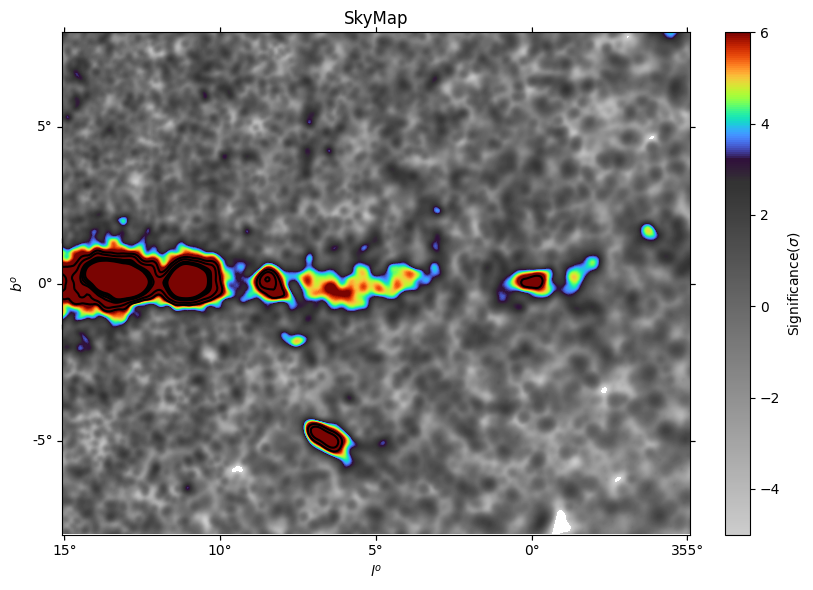

In [227]:
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)

In [228]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

Algorithm will proceed. Significance Map has data greater than 4$\sigma$)


In [229]:
# Preprocessing Step: Floor the image for analysis
print(np.min(array))
print(np.max(array))
if np.min(array) < -6:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

-6.976286094831269
43.93219798373834
Image softly floored to -5 sigma


Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (1445, 379)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (12.89044859, 0.03331358)>
Peak intensity value: 43.93219798373834


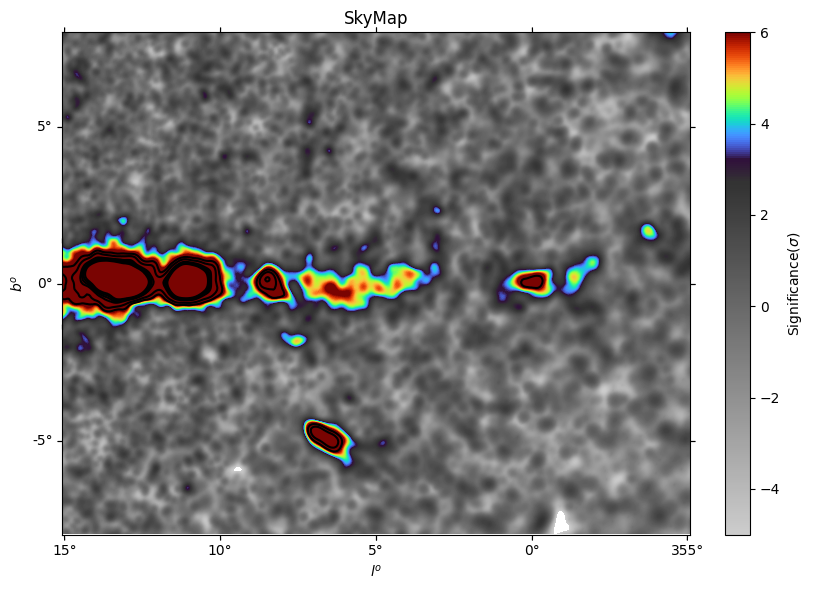

In [230]:
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)

Length of bins=10368


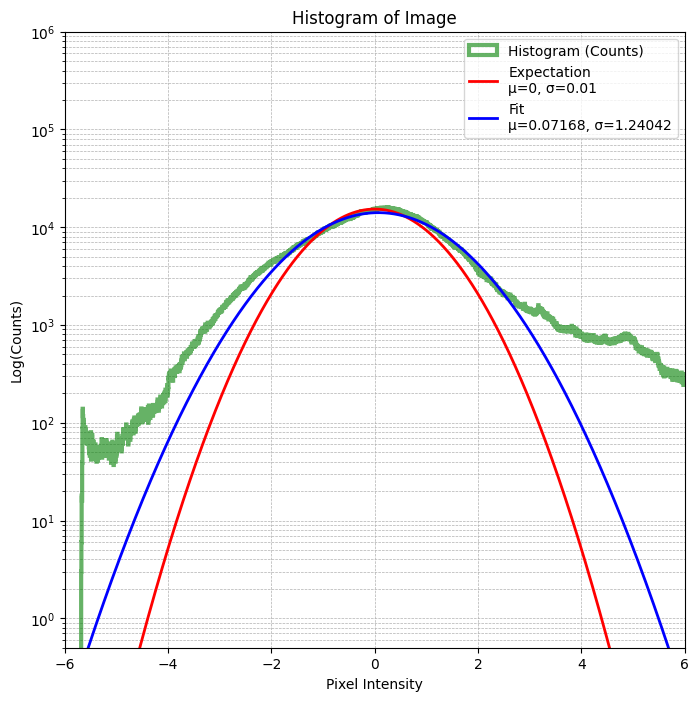

In [231]:
# Calculate the 1D histogram of the image
pixels = array.flatten()
binlen = int(len(pixels)/1000)
print(f"Length of bins={binlen}")
counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(-5, 5, binlen)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
x_fit = np.linspace(-6, np.max(pixels), binlen)
y_fit = gaussian_fit(x_fit, *popt)

plt.figure(figsize=(8, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
plt.yscale('log')
plt.ylim(0.5, 1e6)
plt.xlim(-6, 6)
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>, <WCSAxes: >)

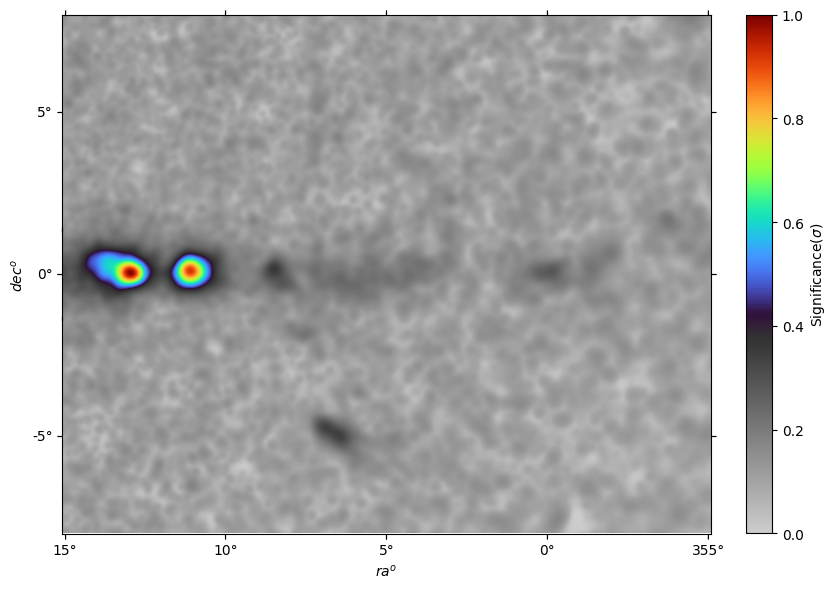

In [232]:
#Normalize the image between 0 and 1 for analysis

image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title=None, hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))

0.02077897337888161 0.7987756133278658


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Smeared Image with radius 0.2$^\\degree$'}>)

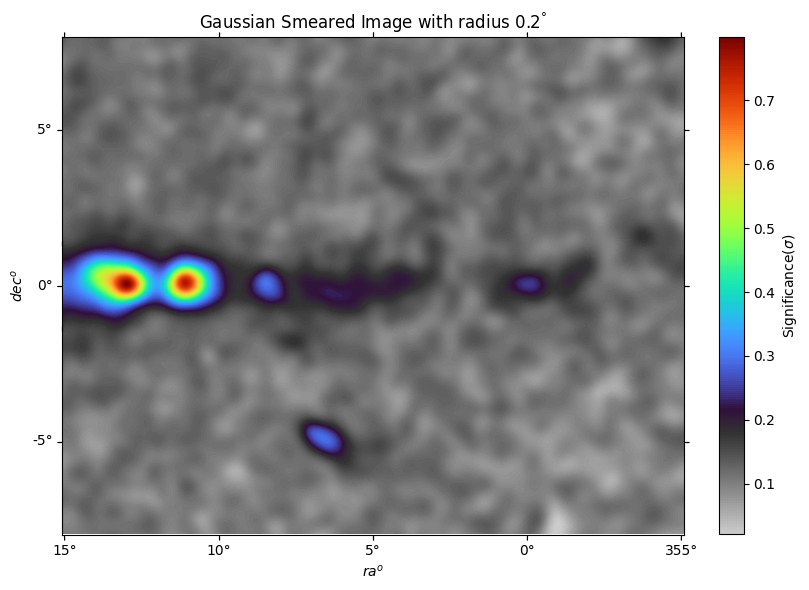

In [233]:
#Smearing Image with a gaussian for visualizing 
image_tmp = norm_image
smear_radius = 0.2
smear_image = gaussian(image_tmp, sigma=smear_radius/pixel_size)
print(np.min(smear_image), np.max(smear_image))
make_plots(smear_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=np.min(smear_image), vmax=np.max(smear_image), title=f"Gaussian Smeared Image with radius {smear_radius}$^\degree$", cmap='ult')

36.0


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

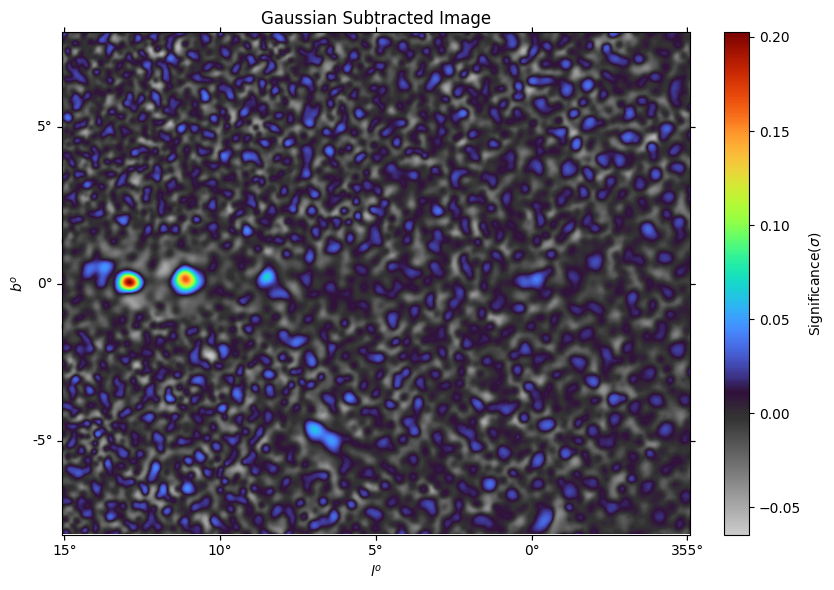

In [257]:
# Find the Difference of Gaussian (DoG) Image
psf=0.2             #PSF of the dec band
print(psf/pixel_size)
dog_image = difference_of_gaussians(norm_image, 1, psf/pixel_size)
# dog_image = gaussian(dog_image)
make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image', cmap='ult')#, labels=['4hawc'])

Significant deviation from Gaussian on positive side at:81,  0.04432


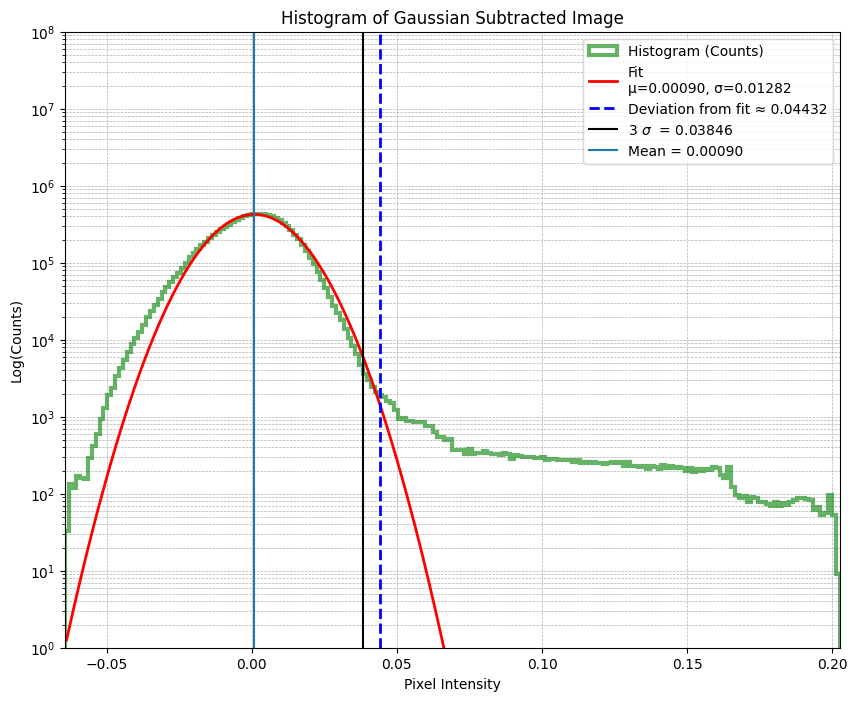

In [258]:
# Calculate the 1D histogram of the DoG Image

pixels = dog_image.flatten()
sigma_resid2 = np.std(dog_image)


counts, bin_edges = np.histogram(pixels, bins=200, range=(np.min(pixels), np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(np.min(bin_edges), np.max(bin_edges), 200)
y_exp = gaussian_fit(x_exp, counts.max(), -0.1, 0.01)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
x_fit = np.linspace(bin_centers[0], bin_centers[-1], 500)
y_fit = gaussian_fit(x_fit, *popt)


fit_interp = interp1d(x_fit, y_fit, bounds_error=False, fill_value=0)
gaussian_at_bins = fit_interp(bin_centers)

# Compute deviation mask: where histogram exceeds Gaussian expectation significantly
deviation_mask = (bin_centers > popt[1]) & (counts > 1.1 * gaussian_at_bins)

for i in range(len(deviation_mask)):
    if np.all(deviation_mask[i:]):
        j = i
        break
deviation_location = bin_centers[j]
print(f"Significant deviation from Gaussian on positive side at:{j},  {deviation_location:.5f}")

sigma_resid = popt[2]
deviation = 3*sigma_resid
plt.figure(figsize=(10, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=200, range=(np.min(pixels), np.max(pixels)),  color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)',histtype='step', linewidth=3)
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
if np.any(deviation_mask):
    plt.axvline(deviation_location, color='blue', linestyle='--', linewidth=2, 
                label=f'Deviation from fit ≈ {deviation_location:.5f}')
plt.axvline(deviation, label=f'3 $\sigma$  = {3*popt[2]:.5f}', color='black')
plt.axvline(popt[1], label=f'Mean = {popt[1]:.5f}')
plt.yscale('log')
plt.ylim(1, 1e8)
plt.xlim(np.min(bin_edges), np.max(bin_edges))
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Gaussian Subtracted Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

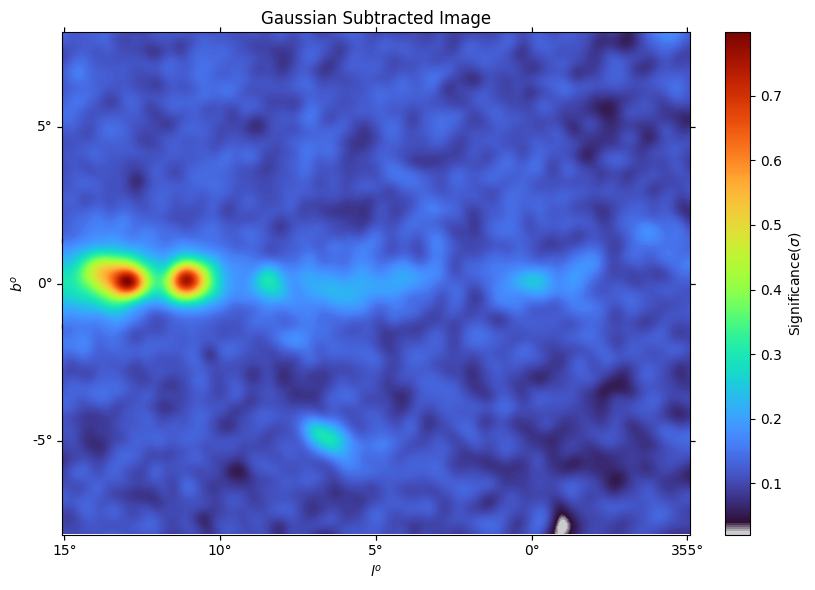

In [259]:
lowfreq_image=norm_image-dog_image
lowfreq_image = gaussian(lowfreq_image, sigma=3)
make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#, figsize=(20, 10))

In [260]:
# Find the blobs from the DoG image
threshold_val = 0.01
ps_blobs = blob_dog(norm_image, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=threshold_val, exclude_border=20, overlap=0.5)
print("Number of point source blobs=",len(ps_blobs))
ext_blobs = blob_dog(norm_image,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=threshold_val, exclude_border=20, overlap=0.5)
print("Number of ext source blobs=",len(ext_blobs))

ps_blobs = ps_blobs[ps_blobs[:, 2] < psf/pixel_size]
ext_blobs = ext_blobs[ext_blobs[:, 2] > psf/pixel_size]
print("Number of point source blobs=",len(ps_blobs))
print("Number of ext source blobs=",len(ext_blobs))

Number of point source blobs= 499
Number of ext source blobs= 210
Number of point source blobs= 499
Number of ext source blobs= 22


In [261]:
# DoG Image Intensity Filtering
deviation=deviation_location
intensity_min = deviation
ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs))
ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ext = ", len(ext_filtered_blobs))

Blob Intensity 0.18568740976331333, Coords (273.3833261490604 deg, -17.779418758175964 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.15549575610762642, Coords (272.39426763203943 deg, -19.325361396993227 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.05640580996874152, Coords (274.84613679195246 deg, -25.256231557449716 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.060761303602622156, Coords (270.9922830682722 deg, -21.56405240108645 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 0.045928885026746524, Coords (274.8810958259402 deg, -25.780604388968136 deg), Radius 28.8, Pixel Radius 0.16
No of ps =  5
Blob Intensity 0.12866962338895974, Coords (272.39207444538107 deg, -19.37502110584367 deg), Radius 57.6, Pixel Radius 0.32
Blob Intensity 0.141863059932414, Coords (273.39128278064425 deg, -17.707563583160283 deg), Radius 57.6, Pixel Radius 0.32
No of ext =  2


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

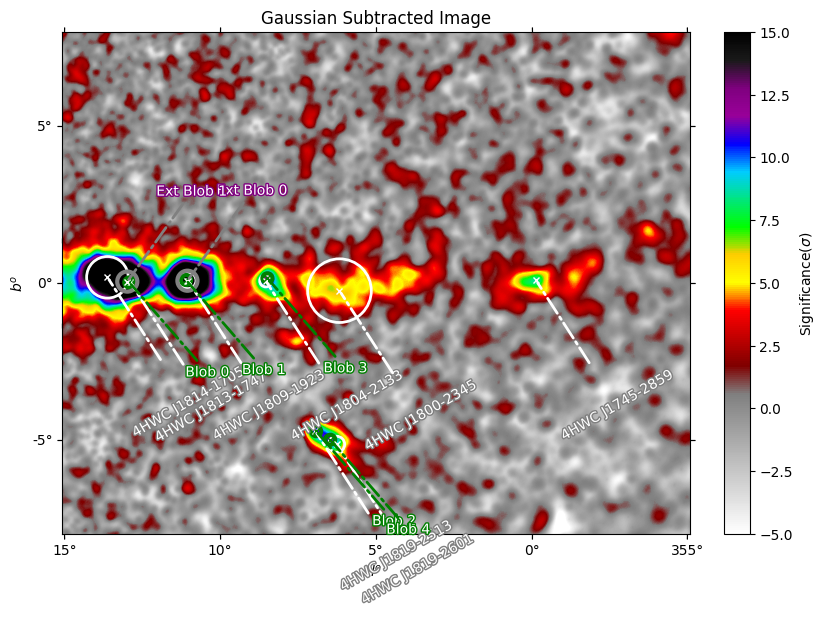

In [262]:
blobs_dict = {
    'psblobs': ps_filtered_blobs,
    'extblobs': ext_filtered_blobs,
}
make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap=milagro, labels=['4hawc'])

In [263]:
# Input Significance Image Intensity Filtering
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))

Blob Intensity 42.17155718476129, Coords (273.3833261490604 deg, -17.779418758175964 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 39.01873228536283, Coords (272.39426763203943 deg, -19.325361396993227 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 10.544184362368288, Coords (274.84613679195246 deg, -25.256231557449716 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 11.744876723732654, Coords (270.9922830682722 deg, -21.56405240108645 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 10.958938697242331, Coords (274.8810958259402 deg, -25.780604388968136 deg), Radius 28.8, Pixel Radius 0.16
Blob Intensity 36.01080263300491, Coords (272.39207444538107 deg, -19.37502110584367 deg), Radius 57.6, Pixel Radius 0.32
Blob Intensity 38.48196936756927, Coords (273.39128278064425 deg, -17.707563583160283 deg), Radius 57.6, Pixel Radius 0.32
No of ps =  5
No of ext =  2


(<Figure size 2000x1000 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

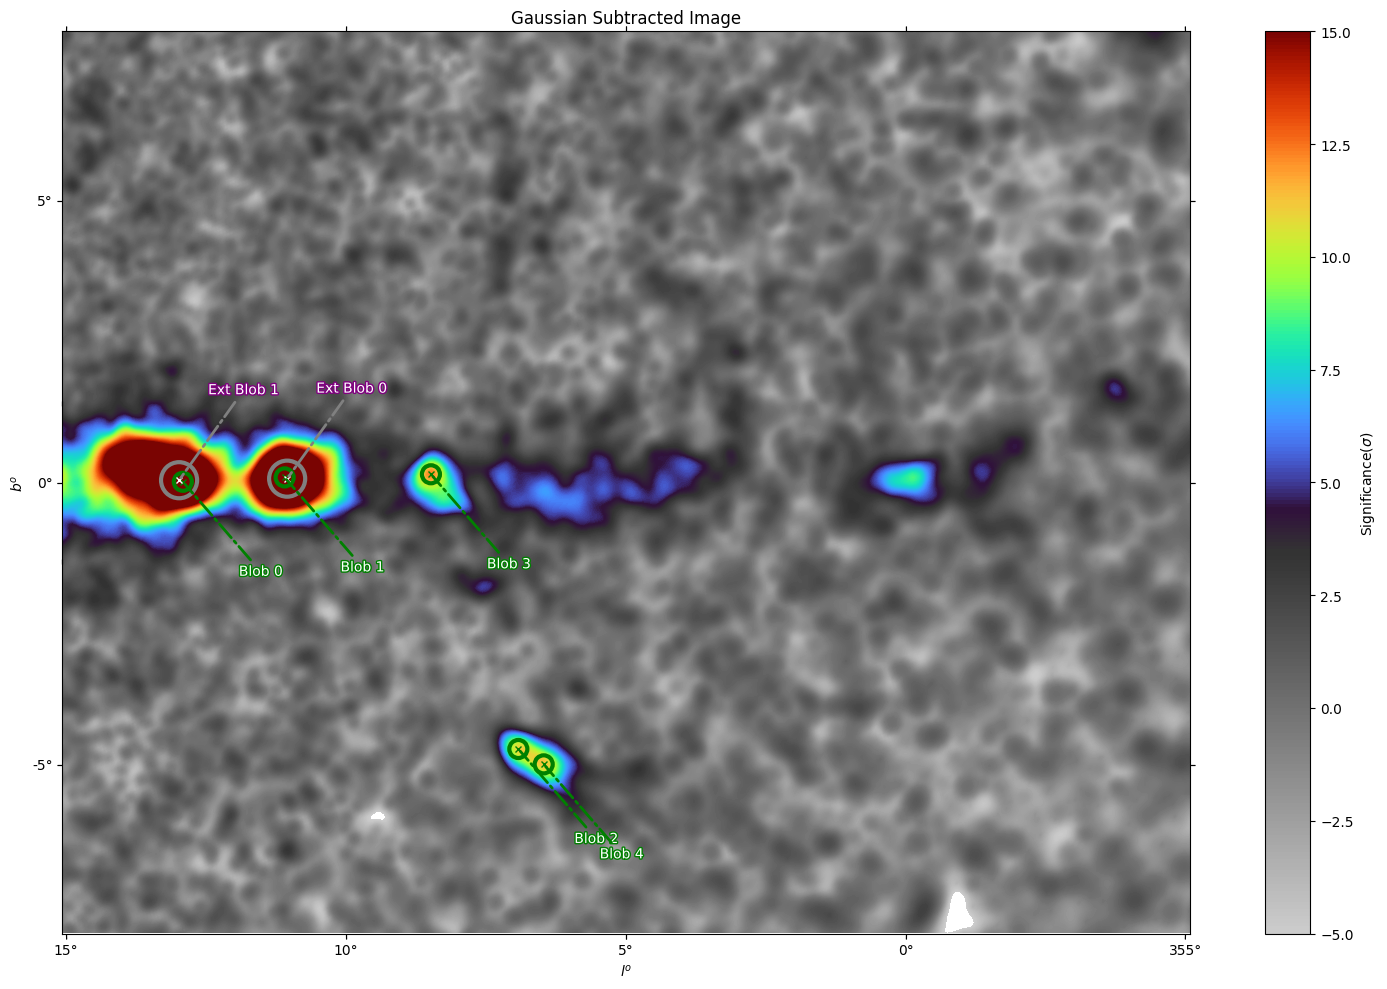

In [264]:
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs3,
}

# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])
make_plots(array, wcs, pixel_size,coordsys='G', blobs=blobs_dict,title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'], figsize=(20, 10))

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

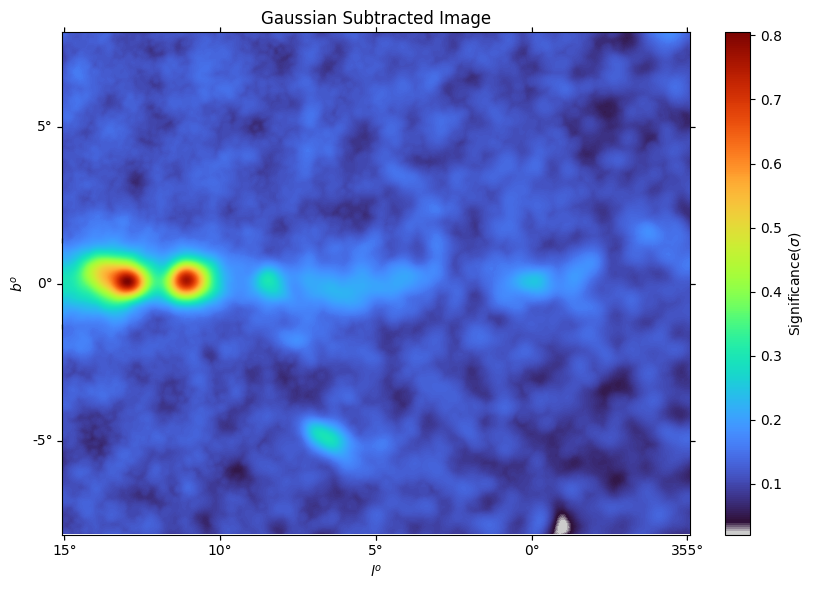

In [265]:
lowfreq_image=norm_image-gaussian(dog_image, sigma=8)
lowfreq_image = gaussian(lowfreq_image, sigma=3)

make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#,

In [266]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs4 = blob_dog(lowfreq_image,min_sigma=0.4/pixel_size, max_sigma=0.8/pixel_size, threshold=0.001, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs4))

Number of ext source blobs= 67


Blob Intensity 33.749645615499325, Coords (272.37442067136294 deg, -19.416617459869844 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 35.04657155579567, Coords (273.41599195744965 deg, -17.606425295168243 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 9.625830007005389, Coords (274.8706279120719 deg, -25.631482162813224 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 9.631005943980684, Coords (271.1067110446807 deg, -21.726058694540512 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 7.001895631011558, Coords (266.43690517000533 deg, -28.869065873932254 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 4.9379556975907555, Coords (269.7978675153588 deg, -24.06998614129931 deg), Radius 115.2, Pixel Radius 0.64
Blob Intensity 4.8969168820880125, Coords (268.7648637797626 deg, -25.356149053544645 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 3.9086933567062365, Coords (265.141147527118 deg, -30.04041625658231 deg), Radius 72.0, Pixel Radius 0.4
Blob Intensity 3.642426112

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

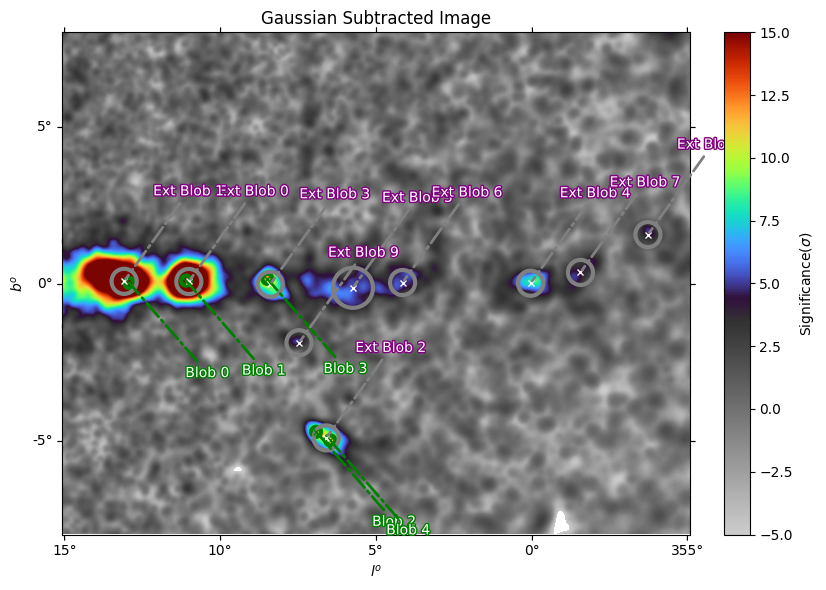

In [267]:
# Filter the Gaussian Blobs from above
ext_filtered_blobs4, ext_filtered_coords4, ext_filtered_radius4 = blob_filter_intensity(ext_blobs4, array, 3, wcs, pixel_size)

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs4,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['mp'])

In [268]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs2 = blob_dog(lowfreq_image,min_sigma=0.8/pixel_size, max_sigma=1.5/pixel_size, threshold=0.005, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs2))

Number of ext source blobs= 10


Blob Intensity 25.346698630999843, Coords (273.4332445630053 deg, -17.495083593767223 deg), Radius 144.0, Pixel Radius 0.8
Blob Intensity 22.91975335185593, Coords (272.4131149192889 deg, -19.316143755533226 deg), Radius 144.0, Pixel Radius 0.8
Blob Intensity 6.321473998674362, Coords (274.89463029587745 deg, -25.793265613015873 deg), Radius 144.0, Pixel Radius 0.8
Blob Intensity 4.756627096886998, Coords (269.8010247910377 deg, -24.020379703954564 deg), Radius 144.0, Pixel Radius 0.8
Blob Intensity 4.713553046162911, Coords (266.40959034551526 deg, -29.004204600981364 deg), Radius 144.0, Pixel Radius 0.8


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

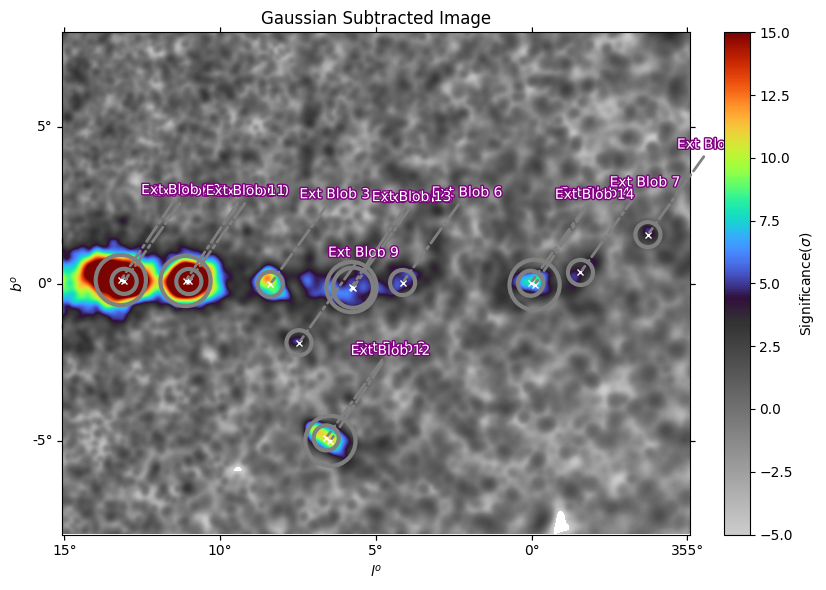

In [269]:
# Filter the Gaussian Blobs from above
ext_filtered_blobs2, ext_filtered_coords2, ext_filtered_radius2 = blob_filter_intensity(ext_blobs2, array, 4.5, wcs, pixel_size)
temp_ext = ext_filtered_blobs4+ext_filtered_blobs2
blobs_dict = {
    # 'psblobs': ps_filtered_blobs2,
    # 'extblobs': ext_filtered_blobs2,
    'extblobs': temp_ext,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult')#, labels=['4hawc'])

In [270]:
from astropy.coordinates import SkyCoord
import astropy.units as u

def remove_overlapping_ext_sources(primary_coords, candidate_coords, threshold_deg=0.3):

    primary = SkyCoord([c.ra.deg for c in primary_coords] * u.deg,
                       [c.dec.deg for c in primary_coords] * u.deg)
    filtered_candidates = []

    for cand in candidate_coords:
        sep = cand.separation(primary)
        if np.all(sep.deg >= threshold_deg):
            filtered_candidates.append(cand)

    return filtered_candidates


def filter_overlapping_sources(coords, radii, radius_to_sigma, name_prefix="Drip", max_distance_deg=0.5):

    df = pd.DataFrame({
        'Names': [f'{name_prefix}{i}' for i in range(len(coords))],
        'ra': [c.ra.deg for c in coords],
        'dec': [c.dec.deg for c in coords],
        'Circle Radius': radii,
    })
    df['Sigma Radius'] = [radius_to_sigma(r) for r in radii]

    keep = np.ones(len(df), dtype=bool)
    skycoords = SkyCoord(ra=df['ra'].values * u.deg, dec=df['dec'].values * u.deg)

    for i in range(len(df)):
        if not keep[i]:
            continue
        sep = skycoords[i].separation(skycoords[i+1:]).deg
        for j_offset, dist in enumerate(sep):
            j = i + 1 + j_offset
            if not keep[j]:
                continue
            if dist < max_distance_deg:
                r1 = df.loc[i, 'Sigma Radius']
                r2 = df.loc[j, 'Sigma Radius']
                if r1 > 0.1 and r2 <= 0.1:
                    keep[j] = False
                elif r2 > 0.1 and r1 <= 0.1:
                    keep[i] = False
                else:
                    keep[j if r1 < r2 else i] = False

    return df[keep].reset_index(drop=True)
def remove_overlapping_ext_sources_with_indices(primary_coords, candidate_coords, threshold_deg=1):
    primary = SkyCoord([c.ra.deg for c in primary_coords] * u.deg,
                       [c.dec.deg for c in primary_coords] * u.deg)

    keep_indices = []
    for idx, cand in enumerate(candidate_coords):
        sep = cand.separation(primary)
        if np.all(sep.deg >= threshold_deg):
            keep_indices.append(idx)
    return keep_indices

from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

def remove_ext_sources_with_radius_overlap(t_coords, t_radii, candidate_coords, candidate_radii):
    """
    Removes candidate sources that overlap with any t_coord based on combined radius.

    Parameters:
    ----------
    t_coords : list of SkyCoord
        Existing sources (points or extended).
    t_radii : list of float
        Angular radii (in degrees) for t_coords.
    candidate_coords : list of SkyCoord
        Candidate extended sources to filter.
    candidate_radii : list of float
        Radii for candidate_coords (degrees).

    Returns:
    -------
    keep_indices : list of int
        Indices of candidate_coords that do NOT overlap with any t_coords.
    """
    assert len(candidate_coords) == len(candidate_radii)
    assert len(t_coords) == len(t_radii)

    t_sky = SkyCoord(ra=[c.ra.deg for c in t_coords] * u.deg,
                     dec=[c.dec.deg for c in t_coords] * u.deg)

    keep_indices = []
    for idx, (cand, r_cand) in enumerate(zip(candidate_coords, candidate_radii)):
        sep = cand.separation(t_sky).deg
        combined_radius = r_cand + np.array(t_radii)
        overlaps = sep <= combined_radius
        if not np.any(overlaps):
            keep_indices.append(idx)

    return keep_indices




In [271]:
all_coords = ps_filtered_coords2 + ext_filtered_coords2 + ext_filtered_coords3 + ext_filtered_coords4
all_radii = ps_filtered_radius2 + ext_filtered_radius2 + ext_filtered_radius3 + ext_filtered_radius4

filtered_df = filter_overlapping_sources(all_coords, all_radii, radius_to_sigma)

In [272]:
t_coords = ps_filtered_coords2 + ext_filtered_coords2
t_radii = ps_filtered_radius2 + ext_filtered_radius2

# Filter ext group 4
valid_idx = remove_ext_sources_with_radius_overlap(
    t_coords, t_radii,
    ext_filtered_coords4, ext_filtered_radius4
)

# Apply filtering
ext_filtered_coords4 = [ext_filtered_coords4[i] for i in valid_idx]
ext_filtered_radius4 = [ext_filtered_radius4[i] for i in valid_idx]
ext_filtered_blobs4  = [ext_filtered_blobs4[i]  for i in valid_idx]

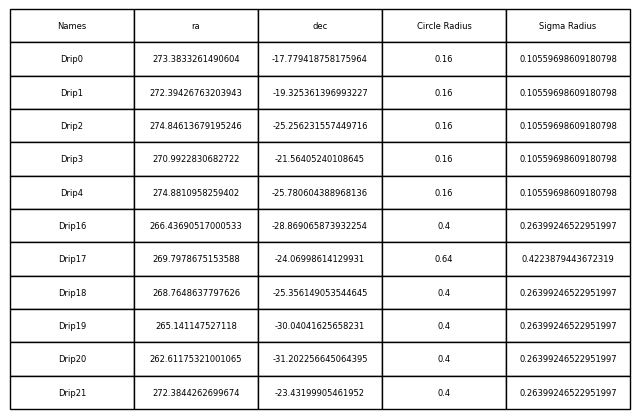

In [273]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
273.3833261490604 -17.779418758175964
272.39426763203943 -19.325361396993227
274.84613679195246 -25.256231557449716
270.9922830682722 -21.56405240108645
274.8810958259402 -25.780604388968136
266.43690517000533 -28.869065873932254
269.7978675153588 -24.06998614129931
268.7648637797626 -25.356149053544645
265.141147527118 -30.04041625658231
262.61175321001065 -31.202256645064395
272.3844262699674 -23.43199905461952


(<Figure size 1600x800 with 2 Axes>, <WCSAxes: title={'center': 'SkyMap'}>)

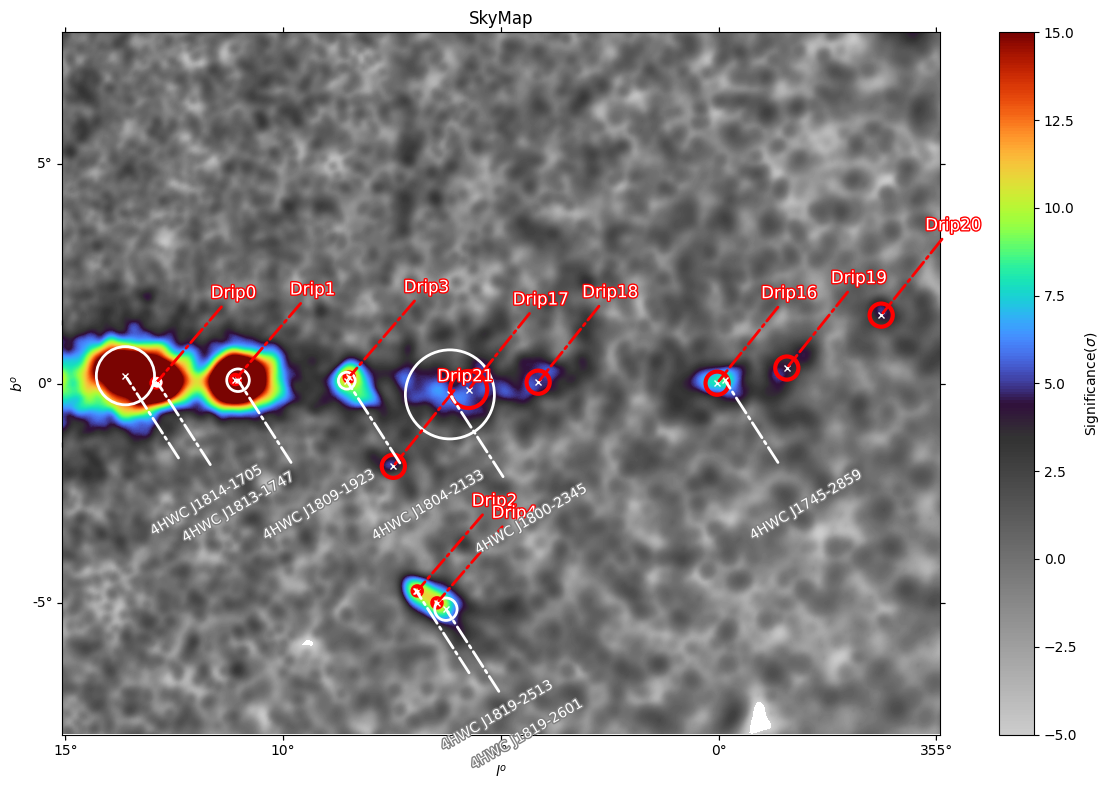

In [279]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs2,
}
# make_plots(array, wcs, pixel_size, coordsys='G', hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc', '4fgl', 'hgps', 'psr', 'snr'], figsize=(20, 10))
# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['N'], figsize=(20, 10))
make_plots(array, wcs, pixel_size,threshold=4, coordsys='G',hotspots=seed_final, title=f'SkyMap', cmap='ult', labels=['4hawc'], save_dir='./', figsize=(16, 8))

In [309]:
from astropy.coordinates import ICRS
from astroquery.simbad import Simbad

In [310]:
otype_dict = {
    'SN*': 'SuperNova',
    'SN?': 'SuperNova',
    'XB*': 'X-ray Binary',
    'XB?': 'X-ray Binary',
    'LXB': 'Low Mass X-ray Binary',
    'LXB?': 'Low Mass X-ray Binary',
    'HXB': 'High Mass X-ray Binary',
    'HXB?': 'High Mass X-ray Binary',
    'Psr': 'Pulsar',
    'SFR': 'Star Forming Region',
    'HII': 'HII Region',
    'SNR': 'SuperNova Remnant',
    'SR?': 'SuperNova Remnant',
    'gam': 'Gamma-ray Source',
    'gB': 'Gamma-ray Burst',
    'X': 'X-ray Source',
    'ULX': 'Ultra-luminous X-ray Source',
    'UX?': 'Ultra-luminous X-ray Source',
}
Simbad.add_votable_fields('parallax', 'mesdistance', 'otype') 
Simbad.get_votable_fields()

['basic.main_id',
 'basic.ra',
 'basic.dec',
 'basic.coo_err_maj',
 'basic.coo_err_min',
 'basic.coo_err_angle',
 'basic.coo_wavelength',
 'basic.coo_bibcode',
 'basic.otype',
 'mesdistance.bibcode',
 'mesdistance.dist',
 'mesdistance.dist_prec',
 'mesdistance.mespos',
 'mesdistance.method',
 'mesdistance.minus_err',
 'mesdistance.minus_err_prec',
 'mesdistance.plus_err',
 'mesdistance.plus_err_prec',
 'mesdistance.qual',
 'mesdistance.unit',
 'basic.plx_err',
 'basic.plx_value',
 'basic.plx_qual',
 'basic.plx_err_prec',
 'basic.plx_prec',
 'basic.plx_bibcode',
 'basic.otype',
 'mesdistance.bibcode',
 'mesdistance.dist',
 'mesdistance.dist_prec',
 'mesdistance.mespos',
 'mesdistance.method',
 'mesdistance.minus_err',
 'mesdistance.minus_err_prec',
 'mesdistance.plus_err',
 'mesdistance.plus_err_prec',
 'mesdistance.qual',
 'mesdistance.unit',
 'basic.plx_err',
 'basic.plx_value',
 'basic.plx_qual',
 'basic.plx_err_prec',
 'basic.plx_prec',
 'basic.plx_bibcode',
 'basic.otype',
 'mesdis

In [318]:
simbad = Simbad()
simbad.ROW_LIMIT = 0 

In [322]:
filtered_df

,Names,ra,dec,Circle Radius,Sigma Radius
0,Drip0,273.383326,-17.779419,0.16,0.105597
1,Drip1,272.394268,-19.325361,0.16,0.105597
2,Drip2,274.846137,-25.256232,0.16,0.105597
3,Drip3,270.992283,-21.564052,0.16,0.105597
4,Drip4,274.881096,-25.780604,0.16,0.105597
5,Drip16,266.436905,-28.869066,0.40,0.263992
6,Drip17,269.797868,-24.069986,0.64,0.422388
7,Drip18,268.764864,-25.356149,0.40,0.263992
8,Drip19,265.141148,-30.040416,0.40,0.263992
9,Drip20,262.611753,-31.202257,0.40,0.263992


In [348]:
list_table = []
sorted_table = []
counterparts = []
snr = []
lmxb = []
hmxb = []
pulsar = []
sfr = []
for i in range(len(filtered_df)):
    source_coord=SkyCoord(ra=filtered_df['ra'][i]*u.degree, dec=filtered_df['dec'][i]*u.degree, frame='icrs')
    source_radius = filtered_df['Sigma Radius'][i] * u.degree
    gal_coords = source_coord.transform_to('galactic')
    result_table = Simbad.query_region(gal_coords, radius=source_radius)
    result_table['distance_pc'] = 1000 / result_table['plx_value'] 
    sorted_table = result_table[result_table['distance_pc'].argsort()]
    df = result_table.to_pandas()
    df_unique = df.drop_duplicates(subset='main_id')
    sorted_df = df_unique.sort_values(by='distance_pc')
    sorted_df['otype_expanded'] = sorted_df['otype'].map(otype_dict).fillna(df['otype'])
    if sorted_df[sorted_df['otype_expanded'] == 'SuperNova Remnant']['main_id'].any():
        snr.append(sorted_df[sorted_df['otype_expanded'] == 'SuperNova Remnant']['main_id'].values)
    else:
        snr.append("None")
    
    if sorted_df[sorted_df['otype_expanded'] == 'Low Mass X-ray Binary']['main_id'].any():
        lmxb.append(sorted_df[sorted_df['otype_expanded'] == 'Low Mass X-ray Binary']['main_id'].values)
    else:
        lmxb.append("None")

    if sorted_df[sorted_df['otype_expanded'] == 'High Mass X-ray Binary']['main_id'].any():
        hmxb.append(sorted_df[sorted_df['otype_expanded'] == 'High Mass X-ray Binary']['main_id'].values)
    else:
        hmxb.append("None")
        
    if sorted_df[sorted_df['otype_expanded'] == 'Pulsar']['main_id'].any():
        pulsar.append(sorted_df[sorted_df['otype_expanded'] == 'Pulsar']['main_id'].values)
    else:
        pulsar.append("None")

    if sorted_df[sorted_df['otype_expanded'] == 'Star Forming Region']['main_id'].any():
        sfr.append(sorted_df[sorted_df['otype_expanded'] == 'Star Forming Region'].values)
    else:
        sfr.append("None")
    
    gammasource =  sorted_df[sorted_df['otype_expanded'] == 'Gamma-ray Source']
    xraysource =  sorted_df[sorted_df['otype_expanded'] == 'X-ray Source']    

In [360]:
counterparts = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "snr": snr,
    "lmxb":  lmxb, 
    "hmxb": hmxb,
    "pulsar":pulsar,
    "sfr": sfr,
    })


In [364]:
with open(f'out{x}_{y}.txt', 'w') as f:
    print('Filename:', filename, file=f)
    for i in range(len(counterparts)):
        print(f"Source: {counterparts['Name'][i]}", file=f)
        print(f"  SNRs: {counterparts['snr'][i]}", file=f)
        print(f"  LMXBs: {counterparts['lmxb'][i]}", file=f)
        print(f"  HMXBs: {counterparts['hmxb'][i]}", file=f)
        print(f"  Pulsars: {counterparts['pulsar'][i]}", file=f)
        print(f"  SFRs: {counterparts['sfr'][i]}", file=f)
        print("--------------------------------------------------", file=f)
